In [ ]:
# Importing libraries using tf.keras for TensorFlow 2.x compatibility
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
#Load the data and split it into train and test 
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 25s 2us/step


In [3]:
#Get the image shape
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


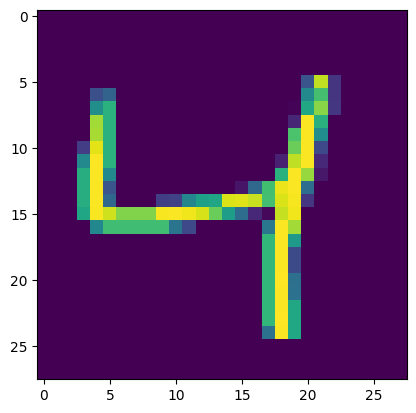

In [4]:
plt.imshow(X_train[2])

In [5]:
# Reshaping the data to fit the model
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

In [6]:
# One-Hot Encoding:
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

# Print the new label
print(y_train_one_hot[0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [8]:
model = Sequential()
model.add(Conv2D(64, kernel_size=3, activation='relu', input_shape=(28,28,1)))
model.add(Conv2D(32, kernel_size=3, activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

c:\Users\sreej\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# patience: Number of epochs with no improvement after which training will be stopped.
# restore_best_weights: Whether to restore model weights from the epoch with the best value of the monitored quantity.

# Then, in your model.fit:
# hist = model.fit(..., callbacks=[early_stopping])

In [11]:
# Train the model
hist = model.fit(X_train, y_train_one_hot, validation_data=(X_test, y_test_one_hot), epochs=10,callbacks=[early_stopping])


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.8402 - loss: 1.1600 - val_accuracy: 0.9777 - val_loss: 0.0707
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9568 - loss: 0.1441 - val_accuracy: 0.9817 - val_loss: 0.0614
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9667 - loss: 0.1141 - val_accuracy: 0.9826 - val_loss: 0.0537
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9709 - loss: 0.0971 - val_accuracy: 0.9860 - val_loss: 0.0491
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9744 - loss: 0.0883 - val_accuracy: 0.9841 - val_loss: 0.0531
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9756 - loss: 0.0795 - val_accuracy: 0.9882 - val_loss: 0.0411
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9793 - loss: 0.0673 - val_accuracy: 0.9875 - val_loss: 0.0441
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9811 -

--- Training History ---
Final Training Accuracy: 0.9825
Final Validation Accuracy: 0.9900
Final Training Loss: 0.0597
Final Validation Loss: 0.0387

--- Model Evaluation on Test Data ---
Test Loss: 0.0387
Test Accuracy: 0.9900
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10

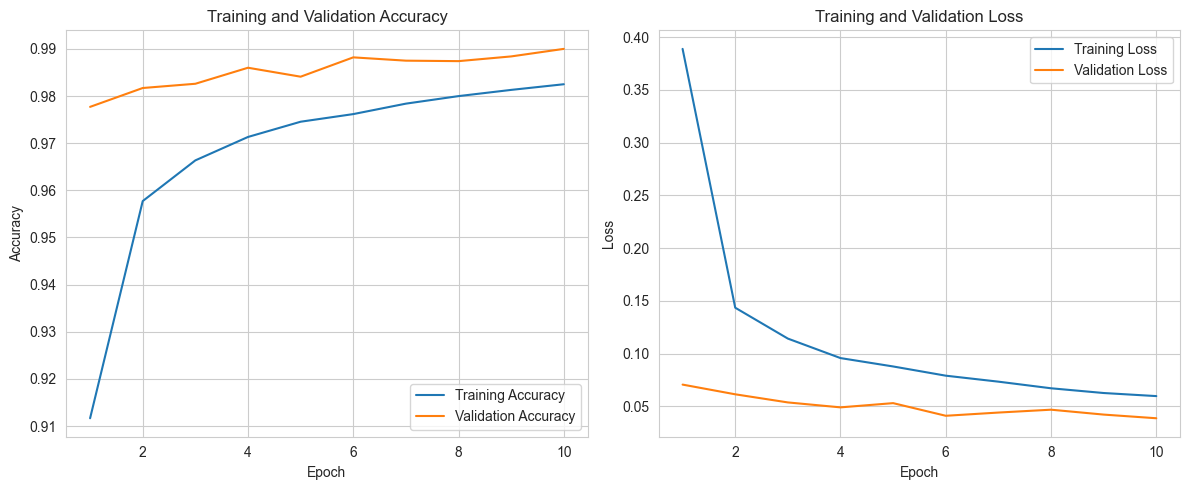

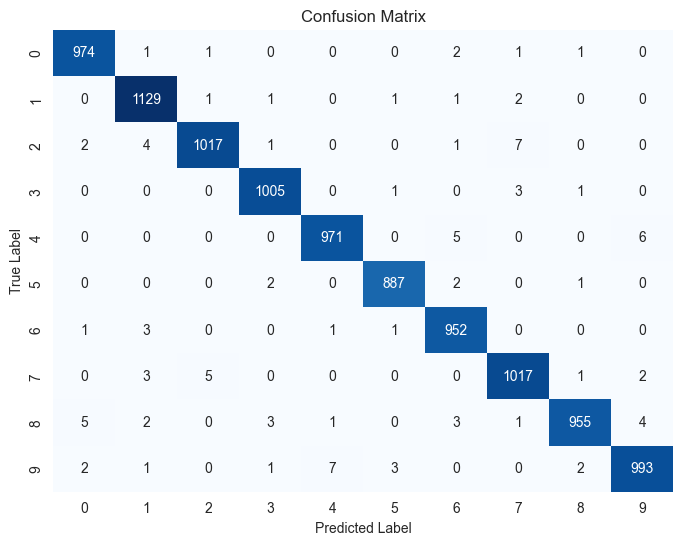

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- 1. Get Accuracy and Loss from Training History ---
print("--- Training History ---")
print(f"Final Training Accuracy: {hist.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {hist.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss: {hist.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {hist.history['val_loss'][-1]:.4f}")

# --- 2. Evaluate the Model on Test Data ---
print("\n--- Model Evaluation on Test Data ---")
loss, accuracy = model.evaluate(X_test, y_test_one_hot, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# --- 3. Make Predictions ---
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1) # Convert probabilities to class labels
y_true = np.argmax(y_test_one_hot, axis=1) # Convert one-hot to class labels

# --- 4. Detailed Evaluation Metrics (Scikit-learn) ---
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
print(cm)

# --- 5. Visualizations with Seaborn ---

# Set style for plots
sns.set_style("whitegrid")

# Plot Training & Validation Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.lineplot(x=range(1, len(hist.history['accuracy']) + 1), y=hist.history['accuracy'], label='Training Accuracy')
sns.lineplot(x=range(1, len(hist.history['val_accuracy']) + 1), y=hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
sns.lineplot(x=range(1, len(hist.history['loss']) + 1), y=hist.history['loss'], label='Training Loss')
sns.lineplot(x=range(1, len(hist.history['val_loss']) + 1), y=hist.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.unique(y_true), yticklabels=np.unique(y_true)) # Assuming class labels are 0, 1, 2...
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Shape of the preprocessed image for prediction: (1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


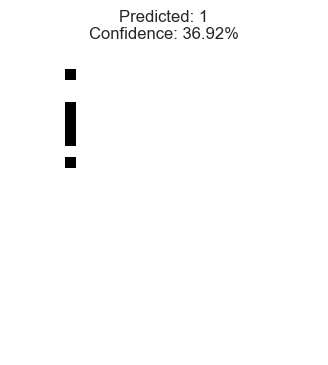


Raw prediction probabilities: [0.01762465 0.3691707  0.0921458  0.04517673 0.149697   0.03487542
 0.02303254 0.2081172  0.02526246 0.03489757]
The model predicts the image is a '1' with 36.92% confidence.


In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load Your Trained Model ---
# Assuming your model object 'model' is still in memory.
# If you're running this in a new session, you'll need to load it.
# If you saved your model earlier:
# from tensorflow.keras.models import load_model
# model = load_model('path/to/your/saved_model.h5')
# Replace 'path/to/your/saved_model.h5' with the actual path if you saved it.

# --- 2. Define Image Path and Class Names ---
image_path = '8.jpg' # Replace with the actual path to your image
# Make sure these class names match the order of your one-hot encoded labels
class_names = [str(i) for i in range(10)] # Assuming 10 classes, 0-9 for MNIST/Fashion MNIST
# If you have specific class names (e.g., for Fashion MNIST), define them here:
# class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
#                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# --- 3. Preprocess the Image ---
# The preprocessing steps *must* match what you did for your training data (X_train).
# Common steps include: resizing, converting to grayscale (if applicable), normalizing.

# Load the image
img = image.load_img(image_path, color_mode='grayscale', target_size=(28, 28)) # Adjust target_size if your images are different

# Convert to a NumPy array
img_array = image.img_to_array(img)

# Expand dimensions to create a batch of 1 (required by model.predict)
# If your model expects (batch_size, height, width, channels), then:
img_array = np.expand_dims(img_array, axis=0) # Becomes (1, 28, 28, 1)

# Normalize the image pixels (important! Match your training normalization)
# If you normalized your training data to 0-1 range:
img_array = img_array / 255.0

# If you reshaped your data for training (e.g., for a Dense layer input in a simple MLP)
# img_array = img_array.reshape(1, 28*28) # Or whatever shape your model expects

print(f"Shape of the preprocessed image for prediction: {img_array.shape}")

# --- 4. Make a Prediction ---
predictions = model.predict(img_array)

# The output `predictions` will be an array of probabilities (e.g., [0.01, 0.05, ..., 0.92]).
# Get the predicted class (the one with the highest probability)
predicted_class_index = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_class_index]
confidence = np.max(predictions[0]) * 100

# --- 5. Display the Result ---
plt.figure(figsize=(6, 4))
plt.imshow(img.convert('RGB')) # Display the original image (convert to RGB if it was grayscale)
plt.title(f"Predicted: {predicted_class_name}\nConfidence: {confidence:.2f}%")
plt.axis('off')
plt.show()

print(f"\nRaw prediction probabilities: {predictions[0]}")
print(f"The model predicts the image is a '{predicted_class_name}' with {confidence:.2f}% confidence.")

In [6]:
# Save the full model after training
from tensorflow.keras.models import load_model
model = load_model('model.h5')
model.build(input_shape=(None, 28, 28, 1)) # (None for batch size)
model.save("model.h5")

In [12]:
import numpy as np
from tensorflow.keras.models import load_model

model = load_model('model1.h5')

# Load test data
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_test = x_test.astype("float32") / 255.0
x_test = np.expand_dims(x_test, -1)  # (batch, 28, 28, 1)

# Predict
preds = model.predict(x_test)
acc = np.mean(np.argmax(preds, axis=1) == y_test)

print(f"Test Accuracy: {acc:.2%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Accuracy: 99.01%


In [11]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import numpy as np

# Load and preprocess MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)  # (num_samples, 28, 28, 1)
x_test = np.expand_dims(x_test, -1)

# Build a better model
model = Sequential([
    Conv2D(32, kernel_size=3, activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=2),
    Conv2D(64, kernel_size=3, activation='relu'),
    MaxPooling2D(pool_size=2),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train from scratch
model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=5, batch_size=128)

# Evaluate and save
model.save("model1.h5")
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"✅ New Model Accuracy: {test_acc:.2%}")

Epoch 1/5


c:\Users\sreej\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7902 - loss: 0.6573 - val_accuracy: 0.9814 - val_loss: 0.0576
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9648 - loss: 0.1152 - val_accuracy: 0.9866 - val_loss: 0.0388
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9771 - loss: 0.0762 - val_accuracy: 0.9895 - val_loss: 0.0312
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9803 - loss: 0.0648 - val_accuracy: 0.9897 - val_loss: 0.0287
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9825 - loss: 0.0597 - val_accuracy: 0.9901 - val_loss: 0.0291


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9878 - loss: 0.0356
✅ New Model Accuracy: 99.01%
